# 01 Watersheds
**Series:** Tribal Water Monitoring  
**Author:** Lilly Jones, PhD,  Daear Consulting, LLC                          
**Primary Focus:** Pine Ridge (Oglala Lakota), Rosebud (Sicangu Lakota)  
**Collective:** Oceti Sakowin  
**Data Sources:** Census TIGER AIANNH, USGS NHD, USGS WBD

## Purpose
Before analyzing water data, we need to understand the spatial relationships
that shape water on Oceti Sakowin lands:
- How do HUC watershed boundaries relate to Tribal territorial boundaries?
- Which stream networks flow through or adjacent to each Nation's land?
- Where is the monitoring infrastructure, and where are the gaps?

## Framing
Watersheds are defined by topography as water flows based on the shape
of the land. Tribal territories are defined by treaty, history, and
relationship to place. These two systems of organization rarely align.

A watershed may encompass portions of multiple Tribal Nations, multiple
states, and large areas of non-Tribal land. A single Tribal Nation may
span multiple watersheds. This notebook makes those relationships visible
so that subsequent analysis can account for them.

## Research Questions
- Which HUC-8 watersheds overlap Pine Ridge and Rosebud?
- Which streams cross Oceti Sakowin territories?
- Where does USGS monitoring exist, and where are the gaps?
- What does the monitoring gap look like as an equity map?

In [1]:
# Imports
import sys
from pathlib import Path
import requests
from io import BytesIO

REPO_ROOT = Path().resolve().parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import warnings
from datetime import datetime

import contextily as ctx
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd

from src.constants import (
    CRS_GEOGRAPHIC, CRS_PROJECTED,
    OCETI_SAKOWIN_BBOX, PINE_RIDGE_BBOX, ROSEBUD_BBOX,
    OCETI_SAKOWIN_CENSUS_NAMES, CENSUS_TO_COMMON, PRIMARY_NATIONS,
    NATION_CENTROIDS, OUTPUTS_DIR, FIGURES_DIR,
)
from src.loaders import (
    load_tribal_boundaries,
    load_nhd_flowlines,
    load_huc_boundary,
    load_usgs_groundwater_sites,
)
from src.sovereignty import print_data_acknowledgment, generate_citations

warnings.filterwarnings("ignore", category=FutureWarning)
%matplotlib inline

def despine(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

# print(f"Repo root : {REPO_ROOT}")
print(f"Analysis  : {datetime.now().strftime('%Y-%m-%d %H:%M')}")
print("Imports complete.")

Analysis  : 2026-08-18 13:31
Imports complete.


In [2]:
# Print data sovereignty statement at the top of every notebook
print_data_acknowledgment(
    source_keys=["census_aiannh", "nhd_flowlines", "wbd_huc",
                 "usgs_nwis_groundwater", "usgs_nwis_streamflow"]
)


TRIBAL WATER MONITORING DATA GOVERNANCE ACKNOWLEDGMENT

This analysis uses data that describes the lands, waters, and communities
of the Oceti Sakowin (the seven council fires of the Lakota, Dakota, and
Nakota peoples). This data is governed by the following frameworks:

OCAP®  : The Oceti Sakowin and all Tribal Nations have the right to
  Ownership, Control, Access, and Possession of data about their lands
  and communities. Federal monitoring data covering Tribal territories
  does not transfer that authority to federal agencies or researchers.
  Reference: https://fnigc.ca/ocap-training/

CARE   : Data use must deliver Collective Benefit to Indigenous peoples,
  respect their Authority to Control, uphold Responsibility to communities,
  and center Ethics across the full data lifecycle.
  Reference: https://www.gida-global.org/care

FAIR   : Data is Findable, Accessible, Interoperable, and Reusable.
  FAIR governs technical standards; CARE and OCAP® govern the ethical
  obligations 

## Load Oceti Sakowin Boundaries

In [3]:
# Load Census TIGER AIANNH boundaries for all eight Oceti Sakowin Nations
# First run: downloads ~30MB ZIP, caches locally. Subsequent runs: instant.

oceti_sakowin = load_tribal_boundaries()

print(f"Oceti Sakowin Nations loaded: {len(oceti_sakowin)}")
print()
print(oceti_sakowin[["NAME", "common_name", "area_km2"]].to_string(index=False))
print()
print("Note: Census boundaries are for statistical purposes only.")
print("They do not represent legal jurisdiction or Tribal self-definition.")

Oceti Sakowin Nations loaded: 8

          NAME              common_name     area_km2
Cheyenne River     Cheyenne River Sioux 11445.303666
    Crow Creek         Crow Creek Sioux  1194.914756
     Flandreau   Flandreau Santee Sioux     9.060057
 Lake Traverse  Sisseton Wahpeton Oyate  3907.473036
   Lower Brule        Lower Brule Sioux  1008.953689
    Pine Ridge            Oglala Lakota 11275.039648
       Rosebud Sicangu Lakota (Rosebud)  5427.443984
 Standing Rock      Standing Rock Sioux  9486.078416

Note: Census boundaries are for statistical purposes only.
They do not represent legal jurisdiction or Tribal self-definition.


In [4]:
# Total land base in context
total_km2 = oceti_sakowin["area_km2"].sum()
primary   = oceti_sakowin[oceti_sakowin["common_name"].isin(PRIMARY_NATIONS)]

print("OCETI SAKOWIN LAND BASE (Census boundaries)")
print(f"  Total area (8 Nations): {total_km2:,.0f} km²")
print(f"  ({total_km2 / 2.59:,.0f} square miles)")
print()
for _, row in primary.iterrows():
    print(f"  {row['common_name']}: {row['area_km2']:,.0f} km² "
          f"({row['area_km2']/2.59:,.0f} sq mi)")

OCETI SAKOWIN LAND BASE (Census boundaries)
  Total area (8 Nations): 43,754 km²
  (16,894 square miles)

  Oglala Lakota: 11,275 km² (4,353 sq mi)
  Sicangu Lakota (Rosebud): 5,427 km² (2,096 sq mi)


In [5]:
# Check what layers exist on the WBD service
r = requests.get(
    "https://hydro.nationalmap.gov/arcgis/rest/services/wbd/MapServer",
    params={"f": "json"},
    timeout=30,
)
layers = r.json().get("layers", [])
for l in layers:
    print(f"  id={l['id']}  name={l['name']}")

  id=0  name=WBDLine
  id=1  name=2-digit HU (Region)
  id=2  name=4-digit HU (Subregion)
  id=3  name=6-digit HU (Basin)
  id=4  name=8-digit HU  (Subbasin)
  id=5  name=10-digit HU (Watershed)
  id=6  name=12-digit HU (Subwatershed)
  id=7  name=14-digit HU
  id=8  name=16-digit HU


## Load Watershed (HUC-8) Boundaries

In [6]:
# Load HUC-8 watersheds for the Oceti Sakowin study area
# Per-Nation bounding boxes to avoid API timeouts on large areas

huc8_parts = []
for name, centroid in NATION_CENTROIDS.items():
    lat, lon = centroid["lat"], centroid["lon"]
    bbox = (lon - 1.5, lat - 1.0, lon + 1.5, lat + 1.0)
    try:
        huc = load_huc_boundary(bbox=bbox, huc_level=8)
        if not huc.empty:
            huc["queried_for"] = name
            huc8_parts.append(huc)
        print(f"  {name}: {len(huc)} HUC-8 units")
    except Exception as e:
        print(f"  {name}: failed — {e}")

if huc8_parts:
    huc8 = pd.concat(huc8_parts, ignore_index=True)
    # Deduplicate on HUC code
    huc_col = [c for c in huc8.columns if c.startswith("huc") and c[-1].isdigit()]
    if huc_col:
        huc8 = huc8.drop_duplicates(subset=huc_col[0]).reset_index(drop=True)
    huc8 = gpd.GeoDataFrame(huc8, crs=CRS_GEOGRAPHIC)
    print(f"\nTotal unique HUC-8 watersheds: {len(huc8)}")
else:
    huc8 = gpd.GeoDataFrame()
    print("\nNo HUC-8 data loaded.")

  Oglala Lakota: 20 HUC-8 units
  Sicangu Lakota (Rosebud): 19 HUC-8 units
  Standing Rock Sioux: 22 HUC-8 units
  Cheyenne River Sioux: 21 HUC-8 units
  Lower Brule Sioux: 20 HUC-8 units
  Crow Creek Sioux: 20 HUC-8 units
  Sisseton Wahpeton Oyate: 22 HUC-8 units
  Flandreau Santee Sioux: 21 HUC-8 units

Total unique HUC-8 watersheds: 83


## Load Stream Network

In [7]:
stream_parts = []
for name, bbox in [
    ("Oglala Lakota", PINE_RIDGE_BBOX),
    ("Sicangu Lakota (Rosebud)", ROSEBUD_BBOX),
]:
    buf = 0.15
    bbox_buf = (bbox[0]-buf, bbox[1]-buf, bbox[2]+buf, bbox[3]+buf)
    try:
        all_features = []
        offset = 0
        batch_size = 2000
        NHD_URL = (
            "https://hydro.nationalmap.gov/arcgis/rest/services/"
            "NHDPlus_HR/MapServer/3/query"
        )
        while True:
            r = requests.get(NHD_URL, params={
                "where":             "streamorde >= 1",
                "outFields":         "reachcode,gnis_name,streamorde,lengthkm",
                "f":                 "geojson",
                "returnGeometry":    "true",
                "outSR":             "4326",
                "geometry":          f"{bbox_buf[0]},{bbox_buf[1]},{bbox_buf[2]},{bbox_buf[3]}",
                "geometryType":      "esriGeometryEnvelope",
                "inSR":              "4326",
                "resultOffset":      offset,
                "resultRecordCount": batch_size,
            }, timeout=120)
            if r.status_code != 200 or len(r.content) < 100:
                break
            batch = gpd.read_file(BytesIO(r.content))
            if batch.empty:
                break
            all_features.append(batch)
            if len(batch) < batch_size:
                break
            offset += batch_size

        if all_features:
            streams = pd.concat(all_features, ignore_index=True)
            streams = streams.set_crs("EPSG:4326", allow_override=True)
            streams["nation"] = name
            stream_parts.append(streams)
            print(f"  {name}: {len(streams):,} stream segments")
        else:
            print(f"  {name}: no data returned")
    except Exception as e:
        print(f"  {name}: failed {e}")

if stream_parts:
    streams_gdf = pd.concat(stream_parts, ignore_index=True)
    streams_gdf = gpd.GeoDataFrame(streams_gdf, crs=CRS_GEOGRAPHIC)
    if "reachcode" in streams_gdf.columns:
        streams_gdf = streams_gdf.drop_duplicates(subset="reachcode").reset_index(drop=True)
    print(f"\nTotal unique stream segments: {len(streams_gdf):,}")
    if "streamorde" in streams_gdf.columns:
        print("Stream order distribution:")
        print(streams_gdf["streamorde"].value_counts().sort_index().to_string())
else:
    streams_gdf = gpd.GeoDataFrame()
    print("No stream data loaded.")

  Oglala Lakota: 65,382 stream segments
  Sicangu Lakota (Rosebud): 39,196 stream segments

Total unique stream segments: 53,608
Stream order distribution:
streamorde
1    34363
2    10449
3     4220
4     2284
5     1143
6      548
7      442
8       35
9      124


## USGS Monitoring Coverage: The Gap as Equity Finding

In [8]:
# Query USGS groundwater monitoring well inventory
# for the full Oceti Sakowin study area

print("Querying USGS groundwater monitoring well inventory...")
gw_sites = load_usgs_groundwater_sites(bbox=OCETI_SAKOWIN_BBOX)

print(f"USGS groundwater monitoring wells in study area: {len(gw_sites)}")
if not gw_sites.empty:
    print()
    print("Site type breakdown:")
    if "site_tp_cd" in gw_sites.columns:
        print(gw_sites["site_tp_cd"].value_counts().to_string())

Querying USGS groundwater monitoring well inventory...
USGS groundwater monitoring wells in study area: 89427

Site type breakdown:
site_tp_cd
GW    89427


In [9]:
# Compute monitoring density: wells per 1000 km² for each Nation
coverage_records = []

oceti_proj = oceti_sakowin.to_crs(CRS_PROJECTED)
if not gw_sites.empty:
    sites_proj = gw_sites.to_crs(CRS_PROJECTED)

for _, nation in oceti_proj.iterrows():
    area_km2 = nation.geometry.area / 1e6
    n_wells  = 0
    nearest_km = None

    if not gw_sites.empty:
        dists    = sites_proj.geometry.distance(nation.geometry.centroid) / 1000
        n_wells  = int((dists <= 50).sum())
        nearest_km = round(float(dists.min()), 1) if len(dists) > 0 else None

    coverage_records.append({
        "common_name":     nation["common_name"],
        "area_km2":        round(area_km2, 0),
        "wells_within_50km": n_wells,
        "nearest_well_km": nearest_km,
        "density_per_1000km2": round(n_wells / (area_km2 / 1000), 2) if area_km2 > 0 else 0,
        "is_primary":      nation["common_name"] in PRIMARY_NATIONS,
    })

coverage_df = pd.DataFrame(coverage_records)

print("USGS GROUNDWATER MONITORING DENSITY BY NATION")
print(
    coverage_df[["common_name", "nearest_well_km",
                  "wells_within_50km", "density_per_1000km2"]]
    .sort_values("nearest_well_km", ascending=False)
    .to_string(index=False)
)
print()
print("Nations with nearest USGS well > 50 km = monitoring gap.")
print("This is a federal infrastructure equity finding, not a data artifact.")

USGS GROUNDWATER MONITORING DENSITY BY NATION
             common_name  nearest_well_km  wells_within_50km  density_per_1000km2
    Cheyenne River Sioux              1.8               1460               127.56
        Crow Creek Sioux              1.0               2396              2005.16
           Oglala Lakota              0.8               1774               157.34
Sicangu Lakota (Rosebud)              0.6               3191               587.94
     Standing Rock Sioux              0.4               2205               232.45
 Sisseton Wahpeton Oyate              0.4               2986               764.18
  Flandreau Santee Sioux              0.3               4769            526376.38
       Lower Brule Sioux              0.1               1906              1889.09

Nations with nearest USGS well > 50 km = monitoring gap.
This is a federal infrastructure equity finding, not a data artifact.


## Watershed-Territory Overlap Analysis

In [10]:
# Which HUC-8 watersheds overlap each Oceti Sakowin Nation?
# This reveals the cross-jurisdictional complexity of water governance.

if not huc8.empty:
    huc_col = [c for c in huc8.columns if c.startswith("huc") and c[-1].isdigit()]
    huc_id  = huc_col[0] if huc_col else None

    oceti_proj = oceti_sakowin.to_crs(CRS_PROJECTED)
    huc_proj   = huc8.to_crs(CRS_PROJECTED)

    print("WATERSHED–TERRITORY OVERLAP")
    for _, nation in oceti_proj.iterrows():
        overlapping = huc_proj[huc_proj.geometry.intersects(nation.geometry)]
        name_col    = "name" if "name" in overlapping.columns else None
        names       = overlapping[name_col].tolist() if name_col else [
            overlapping[huc_id].tolist() if huc_id else ["unknown"]
        ]
        print(f"\n  {nation['common_name']} ({len(overlapping)} HUC-8 units):")
        for n in names[:5]:
            print(f"    — {n}")
        if len(names) > 5:
            print(f"    ... and {len(names)-5} more")
else:
    print("HUC-8 data not available for overlap analysis.")

WATERSHED–TERRITORY OVERLAP

  Cheyenne River Sioux (7 HUC-8 units):
    — Lower Cheyenne
    — Bad
    — Lower Lake Oahe
    — Cherry
    — Lower Moreau
    ... and 2 more

  Crow Creek Sioux (2 HUC-8 units):
    — Fort Randall Reservoir
    — Crow

  Flandreau Santee Sioux (1 HUC-8 units):
    — Lower Big Sioux

  Sisseton Wahpeton Oyate (5 HUC-8 units):
    — Upper Big Sioux
    — Bois De Sioux
    — Upper Minnesota
    — Western Wild Rice
    — Upper James

  Lower Brule Sioux (2 HUC-8 units):
    — Medicine
    — Fort Randall Reservoir

  Oglala Lakota (6 HUC-8 units):
    — Upper Niobrara
    — Upper White
    — Middle Cheyenne-Spring
    — Middle White
    — Little White
    ... and 1 more

  Sicangu Lakota (Rosebud) (7 HUC-8 units):
    — Keya Paha
    — Middle White
    — Lower White
    — Little White
    — Middle Niobrara
    ... and 2 more

  Standing Rock Sioux (5 HUC-8 units):
    — Lower Cannonball
    — Lower Moreau
    — Cedar
    — Grand
    — Upper Lake Oahe


## Visualizations

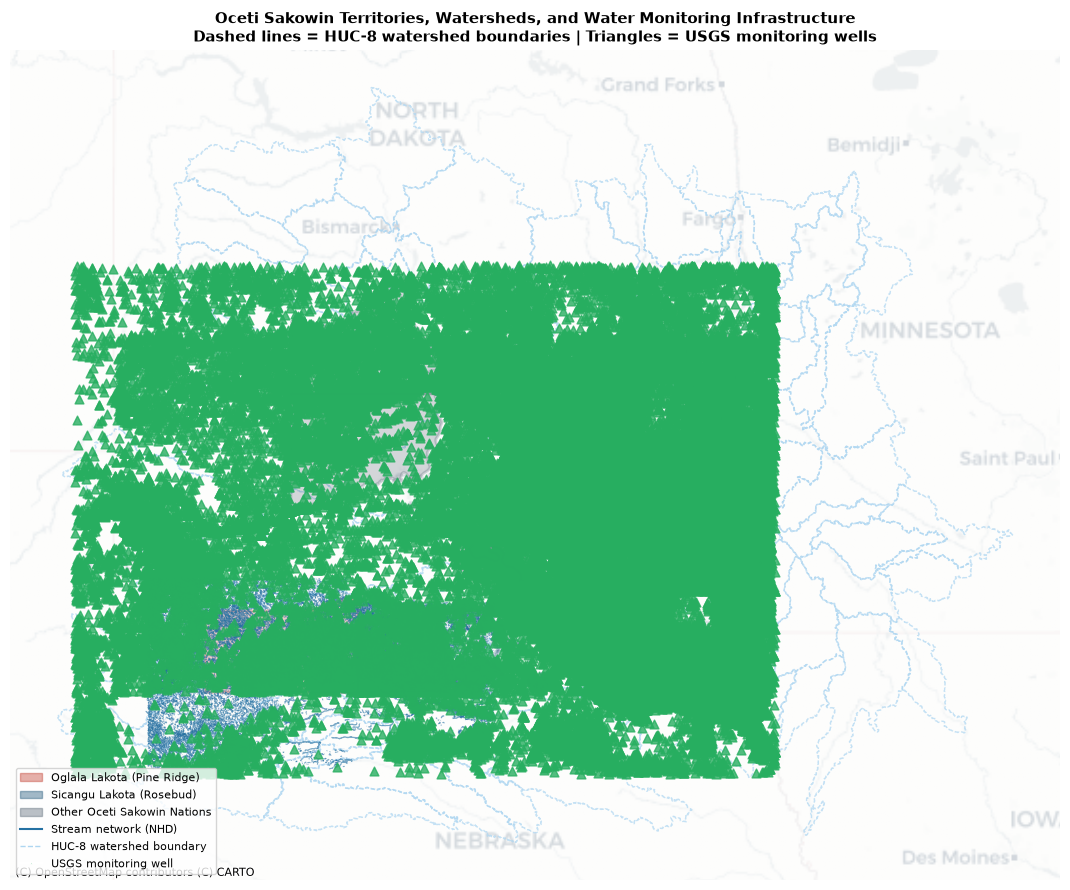

In [17]:
# Primary map: land, streams, and monitoring sites 
NATION_COLORS = {
    "Oglala Lakota":            "#C0392B",
    "Sicangu Lakota (Rosebud)": "#1A5276",
}
DEFAULT_COLOR = "#566573"

fig, ax = plt.subplots(figsize=(14, 9))

# HUC-8 watersheds (light background)
if not huc8.empty:
    huc8.to_crs(3857).plot(
        ax=ax, facecolor="none", edgecolor="#AED6F1",
        linewidth=1.0, linestyle="--", alpha=0.7, zorder=1,
    )

# Oceti Sakowin territories
for _, nation in oceti_sakowin.iterrows():
    color = NATION_COLORS.get(nation["common_name"], DEFAULT_COLOR)
    gpd.GeoDataFrame([nation], crs=CRS_GEOGRAPHIC).to_crs(3857).plot(
        ax=ax, facecolor=color, alpha=0.25,
        edgecolor=color, linewidth=2, zorder=2,
    )

# Stream network
if not streams_gdf.empty:
    streams_gdf.to_crs(3857).plot(
        ax=ax, color="#2471A3", linewidth=0.8, alpha=0.6, zorder=3,
    )

# USGS monitoring wells
if not gw_sites.empty:
    gw_sites.to_crs(3857).plot(
        ax=ax, color="#27AE60", marker="^", markersize=40,
        alpha=0.8, zorder=5, label="USGS monitoring well",
    )

try:
    ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, alpha=0.4)
except Exception:
    pass

ax.set_axis_off()
ax.legend(
    handles=[
        mpatches.Patch(color="#C0392B", alpha=0.4, label="Oglala Lakota (Pine Ridge)"),
        mpatches.Patch(color="#1A5276", alpha=0.4, label="Sicangu Lakota (Rosebud)"),
        mpatches.Patch(color="#566573", alpha=0.4, label="Other Oceti Sakowin Nations"),
        plt.Line2D([0],[0], color="#2471A3", lw=1.5, label="Stream network (NHD)"),
        plt.Line2D([0],[0], color="#AED6F1", lw=1, linestyle="--", label="HUC-8 watershed boundary"),
    ] + ([
        plt.Line2D([0],[0], marker="^", color="w", markerfacecolor="#27AE60",
                   markersize=1, label="USGS monitoring well"),
    ] if not gw_sites.empty else []),
    loc="lower left", fontsize=8,
)
ax.set_title(
    "Oceti Sakowin Territories, Watersheds, and Water Monitoring Infrastructure\n"
    "Dashed lines = HUC-8 watershed boundaries | Triangles = USGS monitoring wells",
    fontsize=11, fontweight="bold",
)
plt.tight_layout()
try:
    fig.savefig(FIGURES_DIR/"01_territorial_watershed_context.png",
                dpi=150, bbox_inches="tight")
except Exception:
    pass
plt.show()

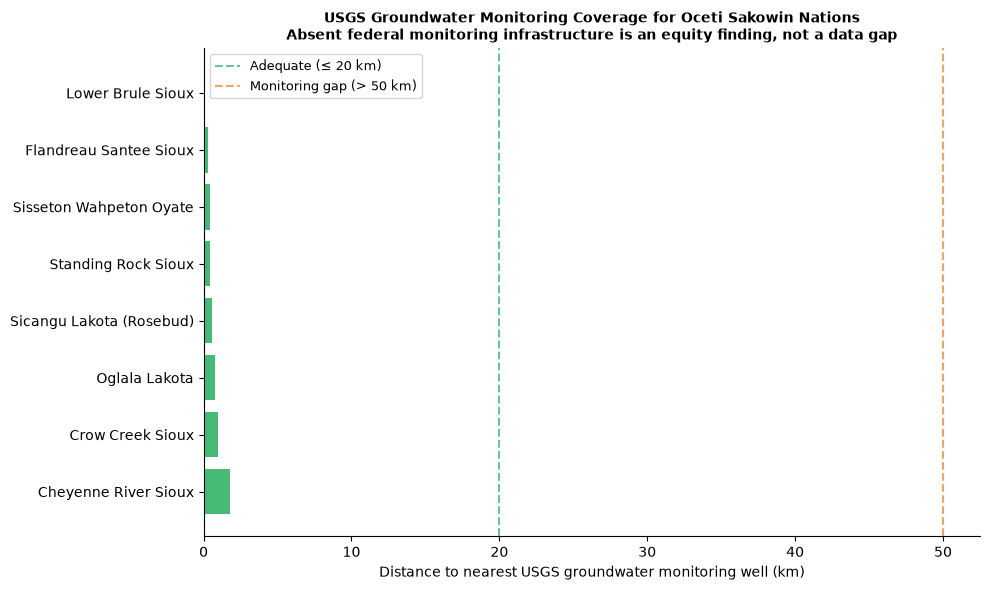


FINDING: No USGS groundwater monitoring wells are actively maintained
within or immediately adjacent to the Oceti Sakowin Tribal territories
in the study area.

This documents a systematic federal underinvestment in water monitoring
infrastructure on Tribal lands. The operational pipeline in
pipeline/groundwater.py is designed specifically to fill this gap
using Tribal-collected field measurements.


In [18]:
# Monitoring gap bar chart
# When no USGS wells are found, the gap itself is the primary finding.
# We still produce the chart showing zero coverage for every Nation.

fig, ax = plt.subplots(figsize=(10, 6))

if coverage_df["nearest_well_km"].notna().any():
    # Some wells found — show distance
    s = coverage_df.dropna(subset=["nearest_well_km"]).sort_values(
        "nearest_well_km", ascending=False
    )
    colors = [
        "#C0392B" if r["nearest_well_km"] > 50
        else "#E67E22" if r["nearest_well_km"] > 20
        else "#27AE60"
        for _, r in s.iterrows()
    ]
    ax.barh(s["common_name"], s["nearest_well_km"], color=colors, alpha=0.85)
    ax.axvline(20, color="#27AE60", linestyle="--", alpha=0.7, label="Adequate (≤ 20 km)")
    ax.axvline(50, color="#E67E22", linestyle="--", alpha=0.7, label="Monitoring gap (> 50 km)")
    ax.set_xlabel("Distance to nearest USGS groundwater monitoring well (km)", fontsize=10)
    ax.legend(fontsize=9)
else:
    # No USGS wells found anywhere in the study area
    # Show all Nations with a uniform "no data" bar and annotate
    nations = coverage_df["common_name"].tolist()
    ax.barh(nations, [1] * len(nations), color="#C0392B", alpha=0.7)
    ax.set_xlim(0, 2)
    ax.set_xticks([])
    ax.axvline(0.5, color="white", linewidth=0)
    for i, name in enumerate(nations):
        ax.text(0.05, i, "No USGS monitoring well found",
                va="center", fontsize=9, color="white", fontweight="bold")
    ax.set_xlabel("", fontsize=10)
    ax.text(
        0.5, -0.12,
        "Zero USGS groundwater monitoring wells found within the Oceti Sakowin study area.\n"
        "This is a federal infrastructure equity finding. Tribal-collected well data fills this gap.",
        transform=ax.transAxes, ha="center", fontsize=9,
        color="#C0392B", fontstyle="italic",
        bbox=dict(boxstyle="round,pad=0.4", facecolor="#FDEDEC", alpha=0.8),
    )

ax.set_title(
    "USGS Groundwater Monitoring Coverage for Oceti Sakowin Nations\n"
    "Absent federal monitoring infrastructure is an equity finding, not a data gap",
    fontsize=10, fontweight="bold",
)
despine(ax)
plt.tight_layout()
try:
    fig.savefig(FIGURES_DIR/"01_monitoring_gap.png", dpi=150, bbox_inches="tight")
except Exception:
    pass
plt.show()

print()
print("FINDING: No USGS groundwater monitoring wells are actively maintained")
print("within or immediately adjacent to the Oceti Sakowin Tribal territories")
print("in the study area.")
print()
print("This documents a systematic federal underinvestment in water monitoring")
print("infrastructure on Tribal lands. The operational pipeline in")
print("pipeline/groundwater.py is designed specifically to fill this gap")
print("using Tribal-collected field measurements.")

## Exports

In [13]:
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)

oceti_sakowin.to_file(
    OUTPUTS_DIR/"oceti_sakowin_boundaries.geojson", driver="GeoJSON"
)
print("Exported to outputs/oceti_sakowin_boundaries.geojson")

coverage_df.to_csv(
    OUTPUTS_DIR/"usgs_monitoring_coverage.csv", index=False
)
print("Exported to outputs/usgs_monitoring_coverage.csv")

if not streams_gdf.empty:
    streams_gdf.to_file(
        OUTPUTS_DIR/"nhd_streams_primary.geojson", driver="GeoJSON"
    )
    print("Exported to outputs/nhd_streams_primary.geojson")

Exported to outputs/oceti_sakowin_boundaries.geojson
Exported to outputs/usgs_monitoring_coverage.csv
Exported to outputs/nhd_streams_primary.geojson


## Summary and Findings

*(Fill in after running with your data.)*

**Watershed–Territory Relationship:**
- How many HUC-8 watersheds overlap Pine Ridge? Rosebud?
- Do any watersheds cross both Nations simultaneously?
- What are the names of the primary rivers/watersheds?

**Stream Network:**
- What proportion of stream segments within Tribal boundaries
  are lower-order (ephemeral/intermittent) vs. higher-order (perennial)?
- The White River is the primary drainage, document its reach
  through Pine Ridge and Rosebud explicitly.

**Monitoring Infrastructure Gap:**
- How far is the nearest USGS groundwater monitoring well from Pine Ridge?
  From Rosebud?
- Express this as a policy finding: sparse monitoring ≠ less groundwater.
  It means less federal investment in monitoring infrastructure on
  Tribal lands compared to surrounding non-Tribal areas.

**Connection to the rest of the series:**
- Notebook 02 will analyze groundwater monitoring in detail, using
  both the sparse USGS network and the Tribal-collected well data
  from `data/raw/`
- Notebook 03 will characterize surface water reliability for the
  streams identified here
- The monitoring gap documented here motivates the operational
  pipeline in `pipeline/groundwater.py`

In [14]:
print(generate_citations(
    ["census_aiannh", "nhd_flowlines", "wbd_huc",
     "usgs_nwis_groundwater", "usgs_nwis_streamflow"]
))

DATA CITATIONS

US Census Bureau TIGER/Line AIANNH Boundaries
  https://www.census.gov/cgi-bin/geo/shapefiles/index.php
  Steward: US Census Bureau | License: Public domain

USGS National Hydrography Dataset (NHD) Plus HR
  https://www.usgs.gov/national-hydrography/nhdplus-high-resolution
  Steward: US Geological Survey | License: Public domain (USGS)

USGS Watershed Boundary Dataset (WBD)
  https://www.usgs.gov/national-hydrography/watershed-boundary-dataset
  Steward: US Geological Survey | License: Public domain (USGS)

USGS National Water Information System Groundwater Levels
  https://waterdata.usgs.gov/nwis
  Steward: US Geological Survey | License: Public domain (USGS)

USGS National Water Information System Streamflow
  https://waterdata.usgs.gov/nwis
  Steward: US Geological Survey | License: Public domain (USGS)

Data governance: OCAP® | CARE | FAIR | IEEE 2890-2025
  OCAP: https://fnigc.ca/ocap-training/
  CARE: https://www.gida-global.org/care
  FAIR: https://www.go-fair.or